<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/). 
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA). 
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

Mon Jun 23 17:59:45 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.76                 Driver Version: 572.76         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro RTX 4000              WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   55C    P8              7W /  110W |     115MiB /   8192MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

2.7.1+cu128


'cuda'

## 1. What are 3 areas in industry where computer vision is currently being used?

Ans: The computer vision is a field that teaches the computers to see. This field has the following applications
1) identification of objects or persons. This application is relevant to cameras installed in self driving autonomous cars, the cameras in smart phones that are able to identify the images of individuals, autonomous idenfication of tumours from X-ray images
2) Identification of text: This application is relevant to the postal services, the identification of pin codes greatly improves the transition time while delivering the mails
3) Identification of anomamalous region: This application is useful in identifying the defective parts from the images

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find. 

Ans: Overfitting in machine learningn refers to a situation wherein the model performs exceptionally well in the training dataset but performs terribly in the test dataset. This means that the model has not learnt the expected signals from the train dataset and cannot be generalized to data not used in the training dataset. Thus, rendering such models useless as they have no predictive power


## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each. 
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

Ans: The following methods could be used to prevent overfitting in machine learning.

1) Enrich the data by collecting more data and ensuring that newly collected data are not exact replica's of the existing data. This can be done by using data augmentation techniques.
2) Use regularization to prevent higher values of model parameters, thus making it harder for the model to rely on just one particular signals in the data
3) Limit the epochs in model training
4) Switch to simpler model i.e. the one with fewer parameters


## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [3]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

transformer = transforms.Compose([transforms.ToTensor()])

train_data = datasets.MNIST(root='./data/',
                            train=True,
                            download=True,
                            transform=transformer)

test_data = datasets.MNIST(root='./data/',
                           train=False,
                           download=True,
                           transform=transformer)

## 6. Visualize at least 5 different samples of the MNIST training dataset.

In [4]:
import random

k = random.choice(train_data)
k[0].shape

torch.Size([1, 28, 28])

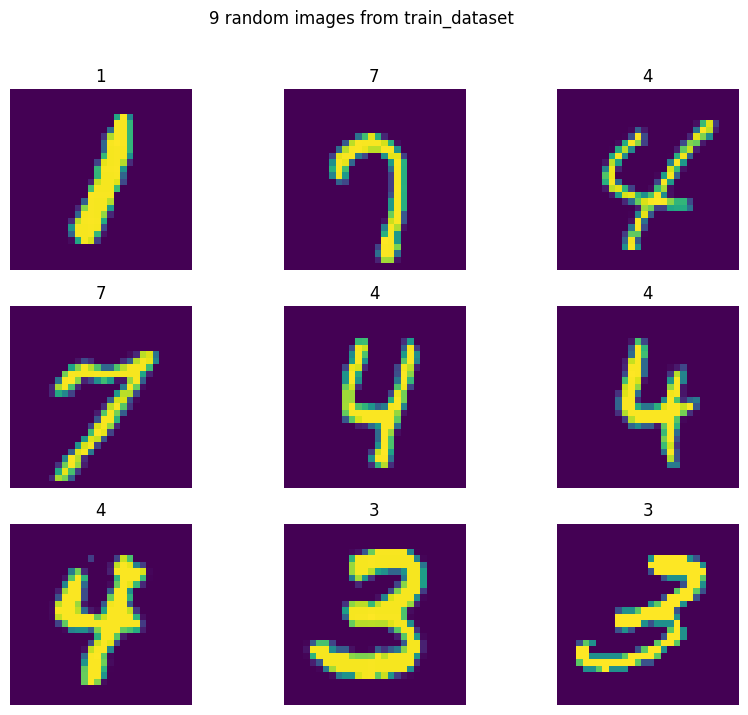

In [5]:
import matplotlib.pyplot as plt
import random

n=9
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(10,8))
ax = ax.flatten()
for i in range(n):
    img, label = random.choice(train_data)
    ax[i].imshow(img.squeeze())
    ax[i].set_title(f"{label}")
    ax[i].grid(False)
    ax[i].set_axis_off()

plt.suptitle("9 random images from train_dataset")
plt.show()



## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [6]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_data,
                              batch_size=32,
                              shuffle=True)
test_dataloader = DataLoader(test_data,
                             batch_size=32,
                             shuffle=True)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [7]:
img.shape

torch.Size([1, 28, 28])

In [8]:
from torch import nn

class TinyVGG(nn.Module):
    def __init__(self, input_neurons, hidden_units, output_neurons):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_neurons,
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding=1,
                      stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding= 1,
                      stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding=1,
                      stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding=1,
                      stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))  # Output: [batch, channels, 1, 1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_neurons)
        )
    
    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x


## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [9]:
# To train the model, Identify the loss function, accuracy, and optimizers first
import torch.optim.optimizer
from torchmetrics import Accuracy


loss_fn = nn.CrossEntropyLoss()

accuracy_fn = Accuracy(task='multiclass',
                       num_classes=10)




In [10]:
def train_model(model, device, accuracy_fn):
    model = model.to(device)
    optimizer = torch.optim.SGD(params=model.parameters(),
                            lr=0.01)
    accuracy_fn = accuracy_fn.to(device)
    epochs = 5
    train_loss_list, test_loss_list = [], []
    train_acc_list, test_acc_list = [], []
    for epoch in range(epochs):
        train_loss_value, test_loss_value = 0, 0
        model.train()
        for X, y in train_dataloader:
            # forward pass
            X, y = X.to(device), y.to(device)
            pred_logits = model(X)

            train_loss = loss_fn(pred_logits, y) #calcualte the loss
            train_loss_value += train_loss.item()

            accuracy_fn.update(pred_logits, y) #queque in the results to calculate the accuracy

            optimizer.zero_grad() # zero the gradients

            train_loss.backward() # back propagate

            optimizer.step() # step against the gradient
        
        train_loss_value /= len(train_dataloader)
        train_loss_list.append(train_loss_value)
        train_acc_value = accuracy_fn.compute()
        accuracy_fn.reset()
        train_acc_list.append(train_acc_value)
        
        model.eval()
        with torch.inference_mode():
            for X, y in test_dataloader:
                X, y = X.to(device), y.to(device)
                pred_logits = model(X)
                test_loss_value += loss_fn(pred_logits, y).item()

                accuracy_fn.update(pred_logits, y)
        
        test_loss_value /= len(test_dataloader)
        test_loss_list.append(test_loss_value)
        test_acc_value = accuracy_fn.compute()
        accuracy_fn.reset()
        test_acc_list.append(test_acc_value)

        print(f"Epoch: {epoch} | Train Loss: {train_loss_value:0.4f} | Train Accuracy: {train_acc_value:.4f} | Test Loss: {test_loss_value:.4f} | Test Accuracy: {test_acc_value:.4f}")

In [11]:
from timeit import default_timer
model_0 = TinyVGG(input_neurons=1, hidden_units=20, output_neurons=10)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
start = default_timer()
train_model(model_0, device, accuracy_fn)
end = default_timer()
print(f"Time taken for training the model on {device}: {end-start} seconds")

Epoch: 0 | Train Loss: 0.7759 | Train Accuracy: 0.7415 | Test Loss: 0.1374 | Test Accuracy: 0.9575
Epoch: 1 | Train Loss: 0.1139 | Train Accuracy: 0.9640 | Test Loss: 0.0839 | Test Accuracy: 0.9741
Epoch: 2 | Train Loss: 0.0821 | Train Accuracy: 0.9747 | Test Loss: 0.0647 | Test Accuracy: 0.9790
Epoch: 3 | Train Loss: 0.0689 | Train Accuracy: 0.9788 | Test Loss: 0.0568 | Test Accuracy: 0.9809
Epoch: 4 | Train Loss: 0.0594 | Train Accuracy: 0.9822 | Test Loss: 0.0527 | Test Accuracy: 0.9832
Time taken for training the model on cuda: 64.73334790000081 seconds


In [12]:

model_1 = TinyVGG(input_neurons=1, hidden_units=20, output_neurons=10)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
start = default_timer()
train_model(model_1, device, accuracy_fn)
end = default_timer()
print(f"Time taken for training the model on {device}: {end-start} seconds")

Epoch: 0 | Train Loss: 1.1033 | Train Accuracy: 0.6333 | Test Loss: 0.1684 | Test Accuracy: 0.9504
Epoch: 1 | Train Loss: 0.1386 | Train Accuracy: 0.9578 | Test Loss: 0.0890 | Test Accuracy: 0.9727
Epoch: 2 | Train Loss: 0.0910 | Train Accuracy: 0.9724 | Test Loss: 0.0769 | Test Accuracy: 0.9748
Epoch: 3 | Train Loss: 0.0721 | Train Accuracy: 0.9783 | Test Loss: 0.0614 | Test Accuracy: 0.9804
Epoch: 4 | Train Loss: 0.0620 | Train Accuracy: 0.9808 | Test Loss: 0.0568 | Test Accuracy: 0.9811
Time taken for training the model on cuda: 69.42962520000037 seconds


In [13]:
model_2 = TinyVGG(input_neurons=1, hidden_units=20, output_neurons=10)
device='cpu'
start = default_timer()
train_model(model_2, device, accuracy_fn)
end = default_timer()
print(f"Time taken for training the model on {device}: {end-start} seconds")

Epoch: 0 | Train Loss: 0.8295 | Train Accuracy: 0.7220 | Test Loss: 0.1326 | Test Accuracy: 0.9598
Epoch: 1 | Train Loss: 0.1239 | Train Accuracy: 0.9620 | Test Loss: 0.0838 | Test Accuracy: 0.9727
Epoch: 2 | Train Loss: 0.0864 | Train Accuracy: 0.9729 | Test Loss: 0.0646 | Test Accuracy: 0.9782
Epoch: 3 | Train Loss: 0.0705 | Train Accuracy: 0.9784 | Test Loss: 0.0574 | Test Accuracy: 0.9821
Epoch: 4 | Train Loss: 0.0609 | Train Accuracy: 0.9811 | Test Loss: 0.0471 | Test Accuracy: 0.9841
Time taken for training the model on cpu: 168.02509720000035 seconds


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

In [14]:
model_2(test_data[0][0].unsqueeze(0)).argmax(dim=1)

tensor([7])

In [15]:
test_data[0][0].shape

torch.Size([1, 28, 28])

In [16]:
t = [(1,3),(2,4),(12,14)]
for x,y in t:
    print(x, y)

1 3
2 4
12 14


found 189 wrong predictions


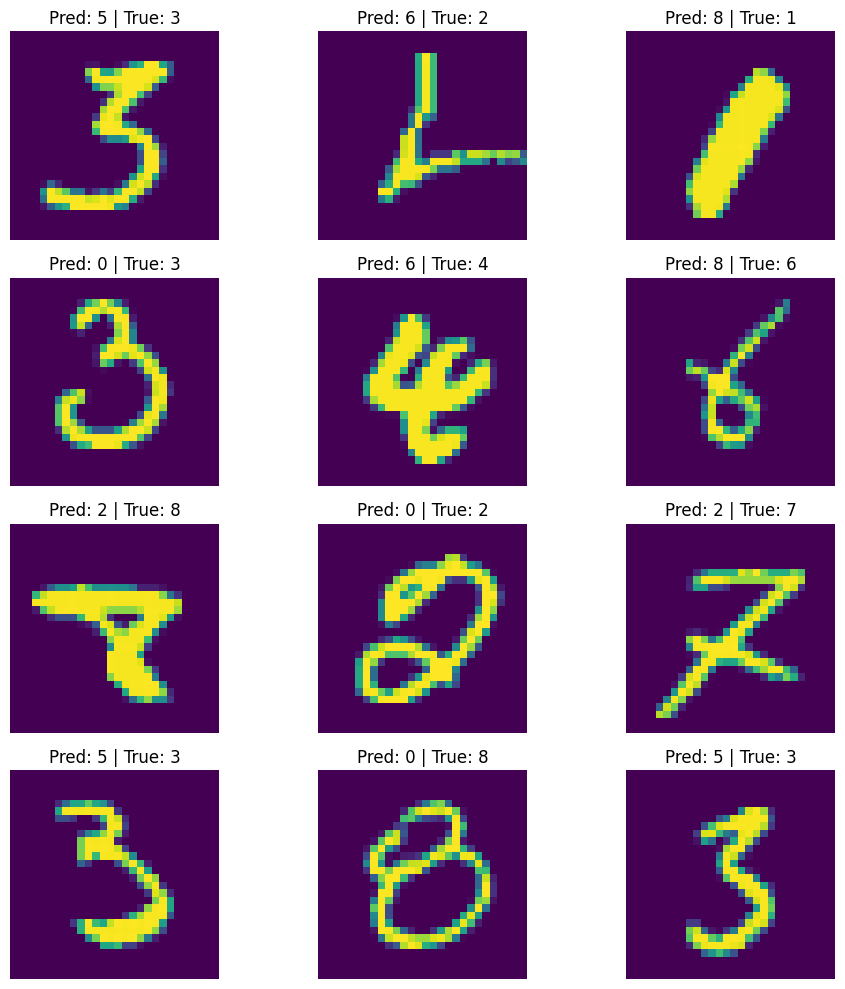

In [17]:
# I am particulary interested in visualization of the wrong predictions

import random
def visualize_wrong_pred(model, device):
    model = model.to(device)
    wrong_pred_idx = []
    for i, (X, y) in enumerate(test_data):
        X = X.to(device)
        with torch.inference_mode():
            pred_logits = model(X.unsqueeze(0))
            if y != pred_logits.argmax(dim=1).item():
                wrong_pred_idx.append((i, pred_logits.argmax(dim=1).item()))
    
    print(f"found {len(wrong_pred_idx)} wrong predictions")

    indices = random.sample(wrong_pred_idx, k=12)
    fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(10,10))
    ax = ax.flatten()
    for i in range(len(indices)):
        ax[i].imshow(test_data[indices[i][0]][0].squeeze())
        ax[i].set_title(f"Pred: {indices[i][1]} | True: {test_data[indices[i][0]][1]}")
        ax[i].grid(False)
        ax[i].set_axis_off()
    
    plt.tight_layout()
    plt.show()



visualize_wrong_pred(model=model_1, device='cuda')

found 159 wrong predictions


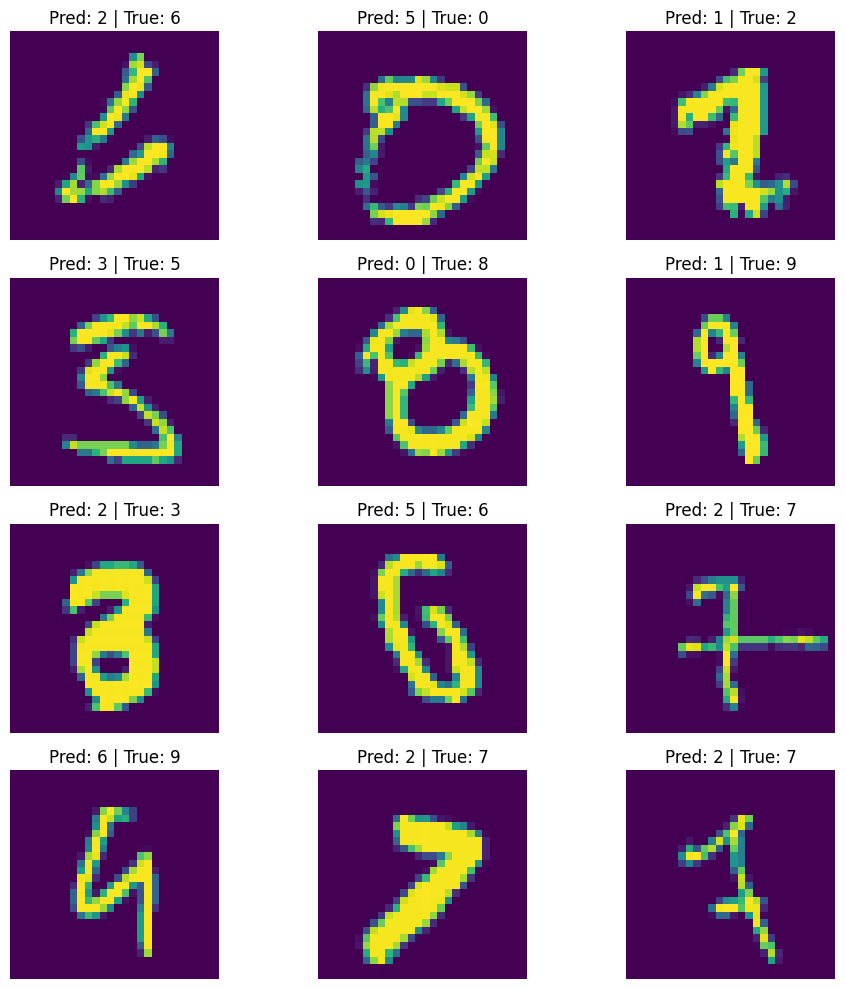

In [18]:
visualize_wrong_pred(model=model_2, device='cpu')

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [19]:
[i.split("-")[1].strip() for i in test_data.classes]

['zero',
 'one',
 'two',
 'three',
 'four',
 'five',
 'six',
 'seven',
 'eight',
 'nine']

(<Figure size 1000x700 with 1 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

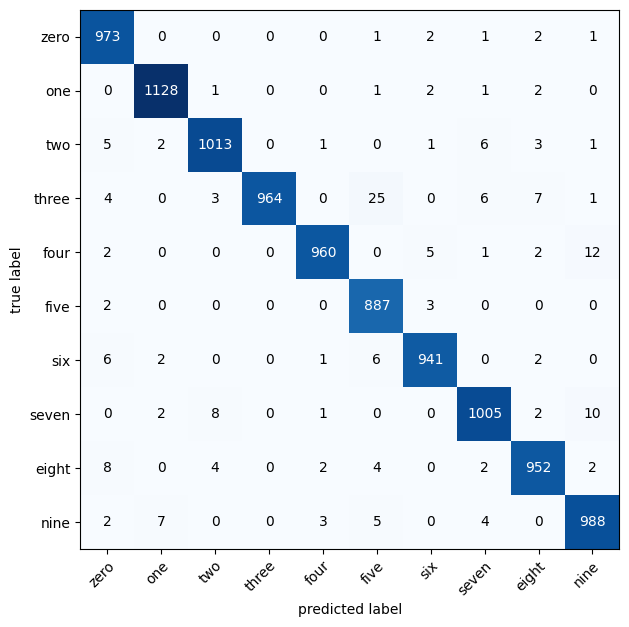

In [20]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
import numpy as np
%matplotlib inline
#get the model predictions
predictions = []
with torch.inference_mode():
    for X, y in test_data:
        pred_logits = model_1(X.to('cuda').unsqueeze(0))
        predictions.append(pred_logits.argmax(dim=1).item())

confusion_matrix = ConfusionMatrix(task='multiclass',
                                   num_classes=10)
conf_mat = confusion_matrix(torch.tensor(predictions),
                 test_data.targets)
plot_confusion_matrix(conf_mat=conf_mat.numpy(),
                      class_names=[i.split("-")[1].strip() for i in test_data.classes],
                      figsize=(10,7))



## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [21]:
rand_tensor = torch.rand(size=(1,3,64,64))
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=5,
                       kernel_size=4)
output = conv_layer(rand_tensor)

print(f"The initial shape: {rand_tensor.shape}\nAfter passing through convolution with kernel size {conv_layer.kernel_size[0]}: {output.shape}")




The initial shape: torch.Size([1, 3, 64, 64])
After passing through convolution with kernel size 4: torch.Size([1, 5, 61, 61])


Ans: As the kernel size increases the output shape is expected to decrease provided other parameter remain the same. Increasing the kernel size leads to more abstraction

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset. 
* Then plot some predictions where the model was wrong alongside what the label of the image should've been. 
* After visualing these predictions do you think it's more of a modelling error or a data error? 
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [22]:
# Let us see if the model trained on MNIST data be used (it shouldn't be)

import torchvision.datasets as dataset
import torchvision.transforms as transform

transformer = transform.Compose(transforms=[transform.ToTensor()])

train_fashionmnist_data = dataset.FashionMNIST(root='./data/',
                                               download=True,
                                               train=True,
                                               transform=transformer)

test_fashionmnist_data = dataset.FashionMNIST(root='./data/',
                                              download=True,
                                              train=False,
                                              transform=transformer)

In [23]:
type(test_fashionmnist_data[0][0])

torch.Tensor

In [24]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
accuracy_fn = Accuracy(task='multiclass',
                       num_classes=10)
accuracy_fn.to(device)
for i, (X, y) in enumerate(test_fashionmnist_data):
    X = X.to(device)
    y = torch.tensor([y], device=device)
    pred_logits = model_1(X.unsqueeze(0))
    accuracy_fn.update(target=y, preds=pred_logits)

acc_value = accuracy_fn.compute()
accuracy_fn.reset()

print(f"The accuracy when model trained on MNIST data is tested on FASHIONMNIST data is {acc_value:0.4f}")

#As expected the value is really a low value

The accuracy when model trained on MNIST data is tested on FASHIONMNIST data is 0.0843


In [25]:
#Instantiating a new model now
from torch import nn
from torch.utils.data import DataLoader
fashion_mnist_model = TinyVGG(input_neurons=1, hidden_units=20, output_neurons=10)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=fashion_mnist_model.parameters(),
                             lr=0.01)

#using the dataloader
train_fashion_mnist_dataloader = DataLoader(dataset=train_fashionmnist_data,
                                            batch_size=32,
                                            shuffle=True)

test_fashionmnist_dataloader = DataLoader(dataset=test_fashionmnist_data,
                                          batch_size=32,
                                          shuffle=True)


In [26]:
def train_model(model, loss_fn, accuracy_fn, optimizer, train_dataloader, test_dataloader, device):
    model = model.to(device)
    accuracy_fn = accuracy_fn.to(device)
    epochs = 10
    train_acc_list, test_acc_list = [],[]
    train_loss_list, test_loss_list = [], []
    for epoch in range(epochs):
        train_loss, test_loss = 0, 0
        for X, y in train_dataloader:
            X, y  = X.to(device), y.to(device)
            model.train()
            pred_logits = model(X)
            loss = loss_fn(pred_logits, y)
            train_loss += loss.item()

            accuracy_fn.update(pred_logits, y)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()
        
        train_loss_value = train_loss / len(train_dataloader)
        train_loss_list.append(train_loss_value)

        train_acc_value = accuracy_fn.compute()
        accuracy_fn.reset()
        train_acc_list.append(train_acc_value)
        with torch.inference_mode():
            model.eval()
            for X, y in test_dataloader:
                X, y = X.to(device), y.to(device)
                pred_logits = model(X)
                loss = loss_fn(pred_logits, y)
                test_loss += loss.item()

                accuracy_fn.update(pred_logits, y)
            
            test_loss_value = test_loss / len(test_dataloader)

            test_acc_value = accuracy_fn.compute()
            accuracy_fn.reset()
            test_acc_list.append(test_acc_value)

        print(f"Epoch: {epoch} | Train Loss: {train_loss_value:0.4f} | Test Loss: {test_loss_value:0.4f} | Train Accuracy: {train_acc_value:0.4f} | Test Accuracy: {test_acc_value:0.4f}")


In [27]:
train_model(model=fashion_mnist_model, 
            loss_fn=loss_fn, 
            accuracy_fn=accuracy_fn, 
            optimizer=optimizer, 
            train_dataloader=train_fashion_mnist_dataloader,
            test_dataloader=test_fashionmnist_dataloader,
            device='cuda')

Epoch: 0 | Train Loss: 0.9969 | Test Loss: 0.5864 | Train Accuracy: 0.6336 | Test Accuracy: 0.7900
Epoch: 1 | Train Loss: 0.5037 | Test Loss: 0.4593 | Train Accuracy: 0.8181 | Test Accuracy: 0.8365
Epoch: 2 | Train Loss: 0.4250 | Test Loss: 0.4116 | Train Accuracy: 0.8477 | Test Accuracy: 0.8529
Epoch: 3 | Train Loss: 0.3797 | Test Loss: 0.3986 | Train Accuracy: 0.8648 | Test Accuracy: 0.8611
Epoch: 4 | Train Loss: 0.3521 | Test Loss: 0.3712 | Train Accuracy: 0.8738 | Test Accuracy: 0.8646
Epoch: 5 | Train Loss: 0.3344 | Test Loss: 0.3418 | Train Accuracy: 0.8795 | Test Accuracy: 0.8814
Epoch: 6 | Train Loss: 0.3188 | Test Loss: 0.3369 | Train Accuracy: 0.8864 | Test Accuracy: 0.8828
Epoch: 7 | Train Loss: 0.3082 | Test Loss: 0.3326 | Train Accuracy: 0.8886 | Test Accuracy: 0.8804
Epoch: 8 | Train Loss: 0.2990 | Test Loss: 0.3245 | Train Accuracy: 0.8919 | Test Accuracy: 0.8836
Epoch: 9 | Train Loss: 0.2900 | Test Loss: 0.3286 | Train Accuracy: 0.8969 | Test Accuracy: 0.8821
